# Image Classifier for Plant Leaf Diseases

**Two-phase approach:**
1. Custom CNN from scratch — understand mechanics
2. Transfer learning with EfficientNetB0 — leverage pretrained features

**Dataset:** New Plant Diseases Dataset (Kaggle)

---

## 0. Setup & Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

2026-04-29 12:13:34.548342: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777464814.750915      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777464814.810351      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777464815.287304      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777464815.287348      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777464815.287352      57 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 1. Data Pipeline

In [2]:
import os

# Correct paths based on Kaggle dataset structure
BASE_PATH = "/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

TRAIN_DIR = os.path.join(BASE_PATH, "train")
VALID_DIR = os.path.join(BASE_PATH, "valid")

IMG_SIZE   = 224
BATCH_SIZE = 32

print(f"Train dir exists : {os.path.exists(TRAIN_DIR)}")
print(f"Valid dir exists : {os.path.exists(VALID_DIR)}")


Train dir exists : True
Valid dir exists : True


In [3]:
# ── Phase 1 Generators (normalized [0,1]) ─────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

val_gen = val_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False,
)

CLASS_NAMES = list(train_gen.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print(f"Classes   : {NUM_CLASSES}")
print(f"Train imgs: {train_gen.samples}")
print(f"Val imgs  : {val_gen.samples}")

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Classes   : 38
Train imgs: 70295
Val imgs  : 17572


In [4]:
# ── Phase 2 Generators (EfficientNet — raw [0,255], no rescale) ───────────────
# EfficientNetB0 has built-in preprocessing — do NOT rescale
train_datagen_eff = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
)

val_datagen_eff = ImageDataGenerator()

train_gen_eff = train_datagen_eff.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

val_gen_eff = val_datagen_eff.flow_from_directory(
    VALID_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False,
)

print("EfficientNet generators ready.")

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
EfficientNet generators ready.


### 1.1 Visualize Raw vs Augmented Samples

I0000 00:00:1777464866.598076      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777464866.604256      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


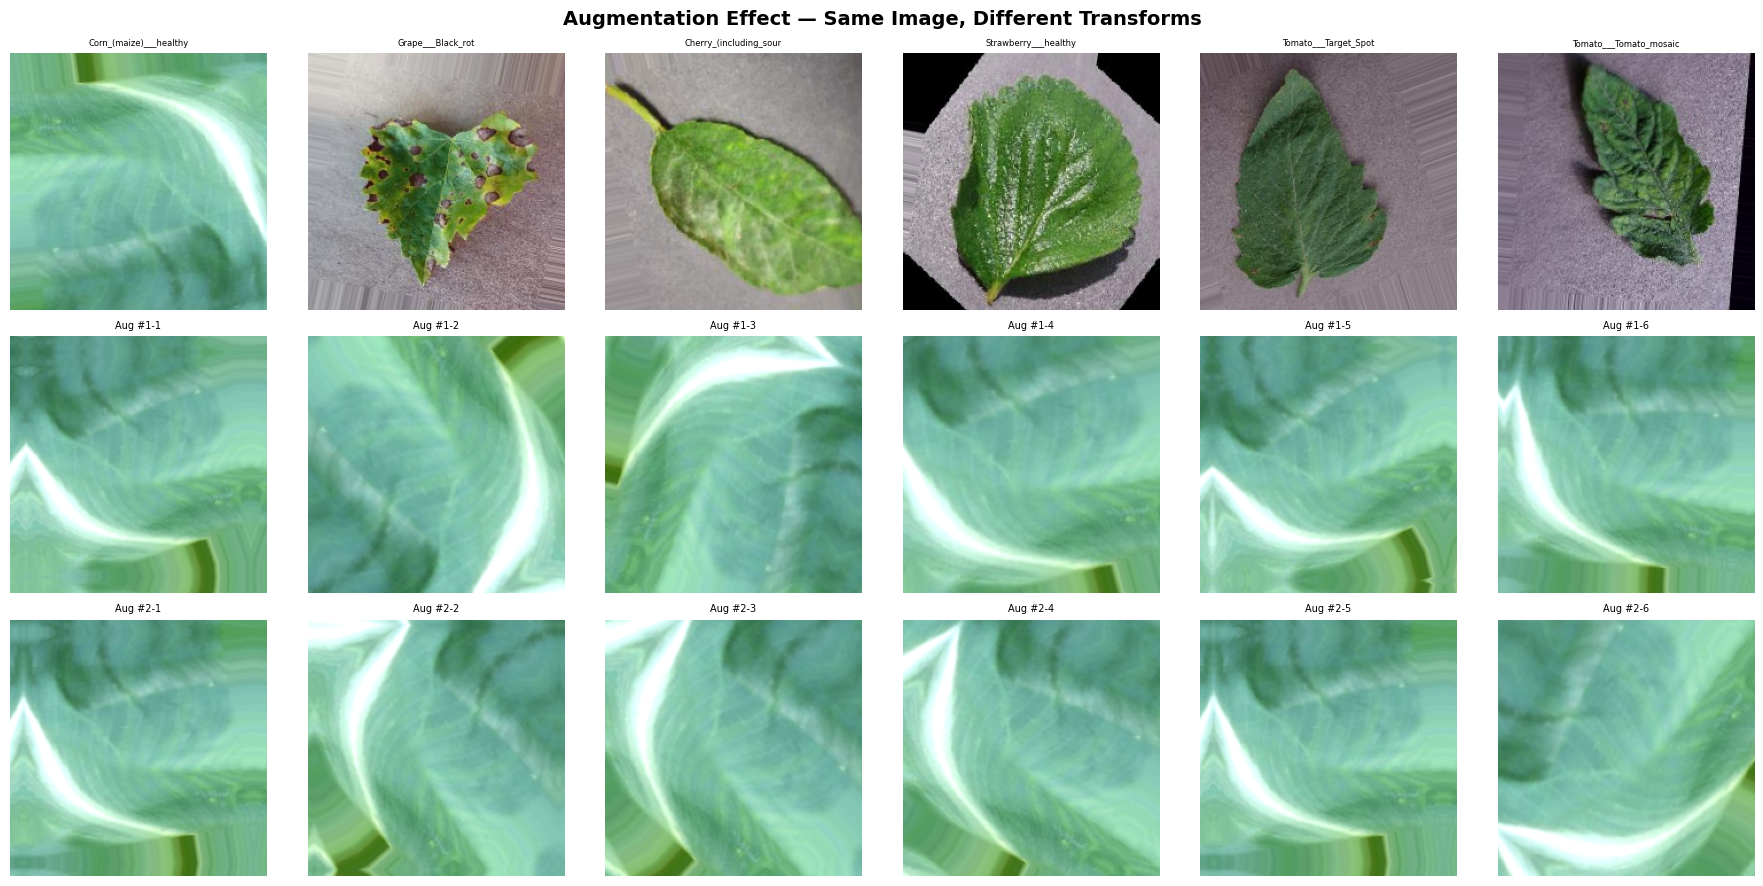

Saved: augmentation_visualization.png


In [5]:
# Grab one batch
sample_images, sample_labels = next(train_gen)

# Augmentation layer for visualization only
aug_layer = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="aug_vis")

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle("Augmentation Effect — Same Image, Different Transforms", fontsize=14, fontweight="bold")

base_img = tf.expand_dims(sample_images[0], axis=0)  # keep batch dim

for col in range(6):
    # Row 0: original samples
    axes[0, col].imshow(sample_images[col])
    axes[0, col].set_title(CLASS_NAMES[int(sample_labels[col])][:22], fontsize=6)
    axes[0, col].axis("off")

    # Row 1-2: augmented versions of the first image
    for row in [1, 2]:
        aug_img = aug_layer(base_img, training=True)[0].numpy()
        aug_img = np.clip(aug_img, 0, 1)
        axes[row, col].imshow(aug_img)
        axes[row, col].set_title(f"Aug #{row}-{col+1}", fontsize=7)
        axes[row, col].axis("off")

axes[0, 0].set_ylabel("Original",    fontsize=10, rotation=90, labelpad=5)
axes[1, 0].set_ylabel("Augmented 1", fontsize=10, rotation=90, labelpad=5)
axes[2, 0].set_ylabel("Augmented 2", fontsize=10, rotation=90, labelpad=5)

plt.tight_layout()
plt.savefig("/kaggle/working/augmentation_visualization.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: augmentation_visualization.png")

---
## Phase 1 — Custom CNN from Scratch

In [6]:
def build_custom_cnn(num_classes: int, input_shape=(224, 224, 3)) -> Model:
    """
    Architecture: 5 × [Conv2D → BN → ReLU → MaxPool → SpatialDropout2D]
    + GlobalAveragePooling + Dense head

    Design rationale
    ----------------
    - BatchNorm  : stabilizes training, reduces LR sensitivity.
    - SpatialDropout2D : drops entire feature maps — better than standard
      Dropout for conv layers (spatially correlated activations).
    - Filter progression 32→512 : hierarchical features (edges→textures→parts).
    - GAP instead of Flatten : fewer params, less overfitting.
    """
    inputs = keras.Input(shape=input_shape, name="input")

    # ── Block 1 ──────────────────────────────────────────────────────────────
    x = layers.Conv2D(32, 3, padding="same", name="conv1")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.SpatialDropout2D(0.1)(x)

    # ── Block 2 ──────────────────────────────────────────────────────────────
    x = layers.Conv2D(64, 3, padding="same", name="conv2")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.SpatialDropout2D(0.15)(x)

    # ── Block 3 ──────────────────────────────────────────────────────────────
    x = layers.Conv2D(128, 3, padding="same", name="conv3")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.SpatialDropout2D(0.2)(x)

    # ── Block 4 ──────────────────────────────────────────────────────────────
    x = layers.Conv2D(256, 3, padding="same", name="conv4")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.SpatialDropout2D(0.25)(x)

    # ── Block 5 ──────────────────────────────────────────────────────────────
    x = layers.Conv2D(512, 3, padding="same", name="conv5")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.GlobalAveragePooling2D()(x)

    # ── Dense head ───────────────────────────────────────────────────────────
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    return Model(inputs, outputs, name="CustomCNN")


cnn_model = build_custom_cnn(NUM_CLASSES)
cnn_model.summary()

phase1_params = cnn_model.count_params()
print(f"\nTotal parameters: {phase1_params:,}")

Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 112, 112, 32)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 56, 56, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 28, 28, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_3             │ (None, 14, 14, 256)    │             0 │
│ (SpatialDropout2D)              │                        │             

 Total params: 1,741,670 (6.64 MB)

 Trainable params: 1,739,686 (6.64 MB)

 Non-trainable params: 1,984 (7.75 KB)


Total parameters: 1,741,670


In [7]:
# ── Compile ───────────────────────────────────────────────────────────────────
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_phase1 = [
    EarlyStopping(
        monitor="val_accuracy", patience=5,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.3,
        patience=3, min_lr=1e-6, verbose=1
    ),
]

# ── Train ─────────────────────────────────────────────────────────────────────
STEPS_PER_EPOCH  = train_gen.samples // BATCH_SIZE
VALIDATION_STEPS = val_gen.samples   // BATCH_SIZE

print("Training Phase 1 — Custom CNN...")
history_cnn = cnn_model.fit(
    train_gen,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=25,
    validation_data=val_gen,
    validation_steps=VALIDATION_STEPS,
    callbacks=callbacks_phase1,
    verbose=1,
)

Training Phase 1 — Custom CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


I0000 00:00:1777464879.696156     157 service.cc:152] XLA service 0x3f84b4e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777464879.696201     157 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777464879.696205     157 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777464880.714849     157 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/2196 ━━━━━━━━━━━━━━━━━━━━ 10:05:23 17s/step - accuracy: 0.0312 - loss: 3.8660

I0000 00:00:1777464891.494731     157 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2196/2196 ━━━━━━━━━━━━━━━━━━━━ 1460s 658ms/step - accuracy: 0.2284 - loss: 2.7581 - val_accuracy: 0.3166 - val_loss: 2.4134 - learning_rate: 0.0010
Epoch 2/25
   1/2196 ━━━━━━━━━━━━━━━━━━━━ 3:45 103ms/step - accuracy: 0.2812 - loss: 2.6182

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2196/2196 ━━━━━━━━━━━━━━━━━━━━ 70s 32ms/step - accuracy: 0.2812 - loss: 2.6182 - val_accuracy: 0.3009 - val_loss: 2.4876 - learning_rate: 0.0010
Epoch 3/25
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 1070s 487ms/step - accuracy: 0.4866 - loss: 1.6926 - val_accuracy: 0.6264 - val_loss: 1.1378 - learning_rate: 0.0010
Epoch 4/25
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.5625 - loss: 1.4656 - val_accuracy: 0.6263 - val_loss: 1.1327 - learning_rate: 0.0010
Epoch 5/25
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 1070s 487ms/step - accuracy: 0.5993 - loss: 1.3018 - val_accuracy: 0.6563 - val_loss: 1.0459 - learning_rate: 0.0010
Epoch 6/25
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy: 0.6875 - loss: 1.0710 - val_accuracy: 0.6514 - val_loss: 1.0742 - learning_rate: 0.0010
Epoch 7/25
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 1069s 487ms/step - accuracy: 0.6541 - loss: 1.0922 - val_accuracy: 0.6838 - val_loss: 1.0126 - learning_rate: 0.0010
Epoch 8/25
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy

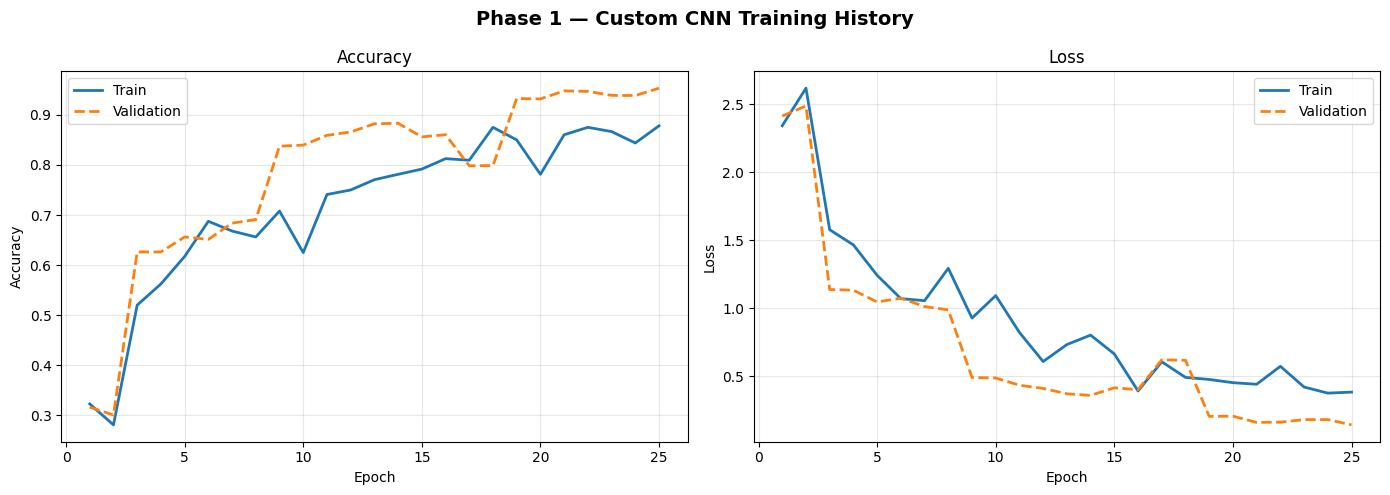

Saved: /kaggle/working/Phase_1__Custom_CNN_Training_History.png


In [8]:
def plot_training_history(history, title="Training History", save_path=None):
    """Plot accuracy and loss curves side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    epochs = range(1, len(history.history["accuracy"]) + 1)

    # Accuracy
    ax1.plot(epochs, history.history["accuracy"],     label="Train",      lw=2)
    ax1.plot(epochs, history.history["val_accuracy"], label="Validation", lw=2, linestyle="--")
    ax1.set_title("Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Loss
    ax2.plot(epochs, history.history["loss"],     label="Train",      lw=2)
    ax2.plot(epochs, history.history["val_loss"], label="Validation", lw=2, linestyle="--")
    ax2.set_title("Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    fname = save_path or f"/kaggle/working/{title.replace(' ', '_').replace('—','')}.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


plot_training_history(history_cnn, "Phase 1 — Custom CNN Training History")

---
## Phase 2 — Transfer Learning with EfficientNetB0

In [27]:
def build_transfer_model(num_classes: int, input_shape=(224, 224, 3)):
    """
    EfficientNetB0 base (frozen) + custom classification head.

    Design rationale
    ----------------
    - include_top=False  : remove ImageNet 1000-class head, keep feature extractor.
    - trainable=False    : freeze base — phase 2a trains head only.
    - Phase 2b           : unfreeze top 30 layers + low LR to adapt domain
                           without catastrophic forgetting.
    """
    inputs = keras.Input(shape=input_shape, name="input")

    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs,
    )
    base_model.trainable = False  # Freeze for phase 2a

    # Classification head
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = Model(inputs, outputs, name="EfficientNetB0_Transfer")
    return model, base_model


eff_model, base_model = build_transfer_model(NUM_CLASSES)
eff_model.summary()

phase2_params_total  = eff_model.count_params()
trainable_frozen     = sum(tf.size(w).numpy() for w in eff_model.trainable_weights)
print(f"\nTotal parameters       : {phase2_params_total:,}")
print(f"Trainable (frozen base): {trainable_frozen:,}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_10        │ (None, 224, 224,  │          0 │ input[0][0]       │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_5     │ (None, 224, 224,  │          7 │ rescaling_10[0][… │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_11        │ (None, 224, 224,  │          0 │ normalization_5[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_11[0][… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,420,425 (16.86 MB)

 Trainable params: 368,294 (1.40 MB)

 Non-trainable params: 4,052,131 (15.46 MB)


Total parameters       : 4,420,425
Trainable (frozen base): 368,294


In [28]:
# ── Phase 2a: Train head only (base frozen) ───────────────────────────────────
STEPS_EFF  = train_gen_eff.samples // BATCH_SIZE
VAL_STEPS  = val_gen_eff.samples   // BATCH_SIZE

eff_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_phase2a = [
    EarlyStopping(
        monitor="val_accuracy", patience=4,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.3,
        patience=2, min_lr=1e-6, verbose=1
    ),
]

print("Phase 2a — Training head (frozen base)...")
history_eff_head = eff_model.fit(
    train_gen_eff,
    steps_per_epoch=STEPS_EFF,
    epochs=10,
    validation_data=val_gen_eff,
    validation_steps=VAL_STEPS,
    callbacks=callbacks_phase2a,
    verbose=1,
)

Phase 2a — Training head (frozen base)...
Epoch 1/10


2026-04-29 17:36:45.377837: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 17:36:45.522535: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 17:36:45.876961: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 17:36:46.026594: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 17:36:46.169670: E external/local_xla/xla/stream_

 829/2196 ━━━━━━━━━━━━━━━━━━━━ 9:02 397ms/step - accuracy: 0.5433 - loss: 1.6435

2026-04-29 17:42:31.707121: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 17:42:31.849461: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 17:42:32.186368: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 17:42:32.328675: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 17:42:33.145056: E external/local_xla/xla/stream_

2196/2196 ━━━━━━━━━━━━━━━━━━━━ 971s 428ms/step - accuracy: 0.6756 - loss: 1.1274 - val_accuracy: 0.9334 - val_loss: 0.1941 - learning_rate: 0.0010
Epoch 2/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - accuracy: 0.9062 - loss: 0.1911 - val_accuracy: 0.9337 - val_loss: 0.1941 - learning_rate: 0.0010
Epoch 3/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 910s 414ms/step - accuracy: 0.8812 - loss: 0.3733 - val_accuracy: 0.9528 - val_loss: 0.1439 - learning_rate: 0.0010
Epoch 4/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - accuracy: 0.9375 - loss: 0.2958 - val_accuracy: 0.9526 - val_loss: 0.1441 - learning_rate: 0.0010
Epoch 5/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 982s 447ms/step - accuracy: 0.9053 - loss: 0.3030 - val_accuracy: 0.9500 - val_loss: 0.1425 - learning_rate: 0.0010
Epoch 6/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - accuracy: 0.9062 - loss: 0.4676 - val_accuracy: 0.9501 - val_loss: 0.1420 - learning_rate: 0.0010
Epoch 7/10
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 1044s 475ms/step - accuracy

In [29]:
# ── Phase 2b: Fine-tune top layers ────────────────────────────────────────────
base_model.trainable = True

UNFREEZE_FROM = len(base_model.layers) - 30
for layer in base_model.layers[:UNFREEZE_FROM]:
    layer.trainable = False

trainable_ft = sum(tf.size(w).numpy() for w in eff_model.trainable_weights)
unfrozen_n   = len([l for l in base_model.layers if l.trainable])
print(f"Trainable params after unfreeze : {trainable_ft:,}")
print(f"Unfrozen layers                 : {unfrozen_n}")

# Low LR — avoid destroying pretrained features
eff_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_phase2b = [
    EarlyStopping(
        monitor="val_accuracy", patience=5,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.3,
        patience=3, min_lr=1e-8, verbose=1
    ),
]

print("Phase 2b — Fine-tuning top layers (low LR)...")
history_eff_finetune = eff_model.fit(
    train_gen_eff,
    steps_per_epoch=STEPS_EFF,
    epochs=20,
    validation_data=val_gen_eff,
    validation_steps=VAL_STEPS,
    callbacks=callbacks_phase2b,
    verbose=1,
)

Trainable params after unfreeze : 1,864,454
Unfrozen layers                 : 30
Phase 2b — Fine-tuning top layers (low LR)...
Epoch 1/20
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 960s 424ms/step - accuracy: 0.8333 - loss: 0.5842 - val_accuracy: 0.9577 - val_loss: 0.1307 - learning_rate: 1.0000e-05
Epoch 2/20
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - accuracy: 0.9375 - loss: 0.2656 - val_accuracy: 0.9577 - val_loss: 0.1307 - learning_rate: 1.0000e-05
Epoch 3/20
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 930s 423ms/step - accuracy: 0.9111 - loss: 0.2923 - val_accuracy: 0.9651 - val_loss: 0.1038 - learning_rate: 1.0000e-05
Epoch 4/20
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - accuracy: 0.9688 - loss: 0.1475 - val_accuracy: 0.9651 - val_loss: 0.1038 - learning_rate: 1.0000e-05
Epoch 5/20
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 927s 422ms/step - accuracy: 0.9326 - loss: 0.2225 - val_accuracy: 0.9697 - val_loss: 0.0890 - learning_rate: 1.0000e-05
Epoch 6/20
2196/2196 ━━━━━━━━━━━━━━━━━━━━ 35s 16ms/step - accuracy:

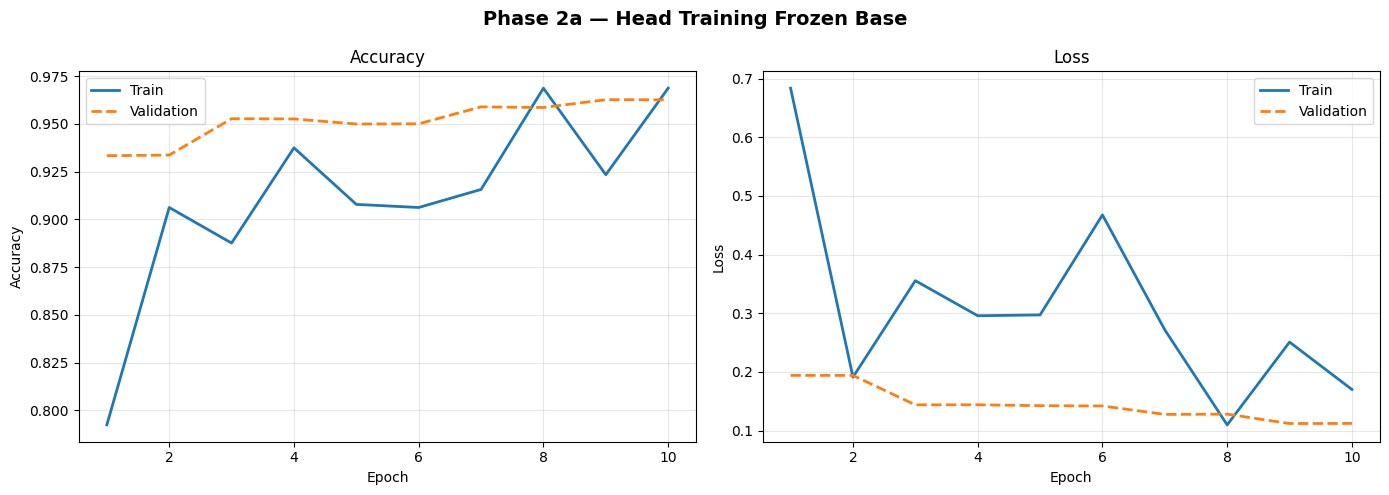

Saved: /kaggle/working/Phase_2a__Head_Training_Frozen_Base.png


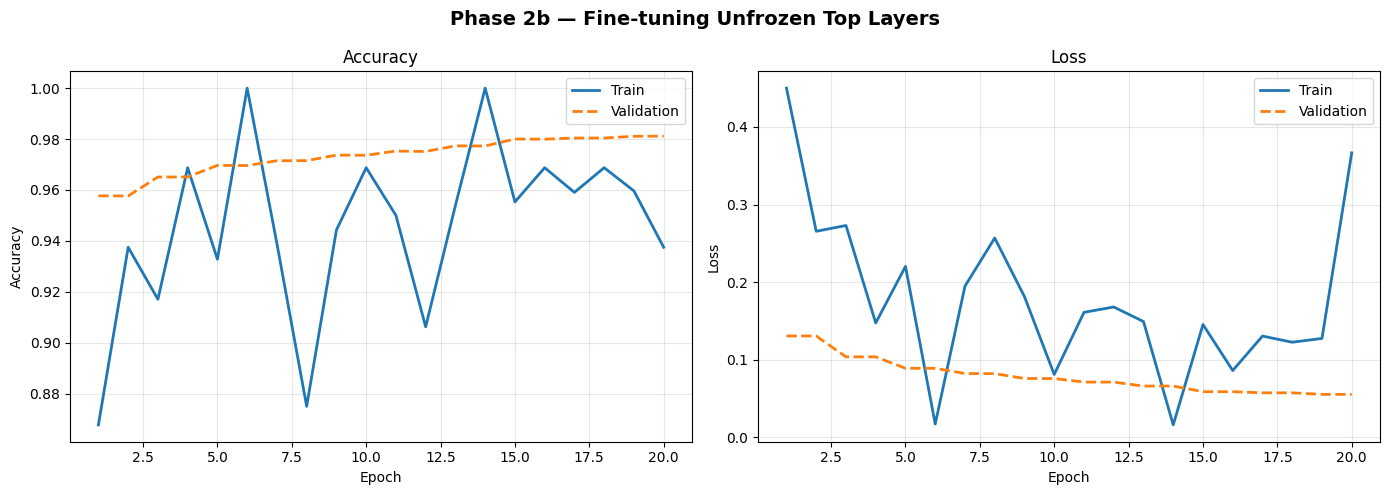

Saved: /kaggle/working/Phase_2b__Fine-tuning_Unfrozen_Top_Layers.png


In [30]:
plot_training_history(history_eff_head,     "Phase 2a — Head Training Frozen Base")
plot_training_history(history_eff_finetune, "Phase 2b — Fine-tuning Unfrozen Top Layers")

---
## 3. Visualization — 9 Sample Predictions

Phase 1 — Custom CNN Predictions


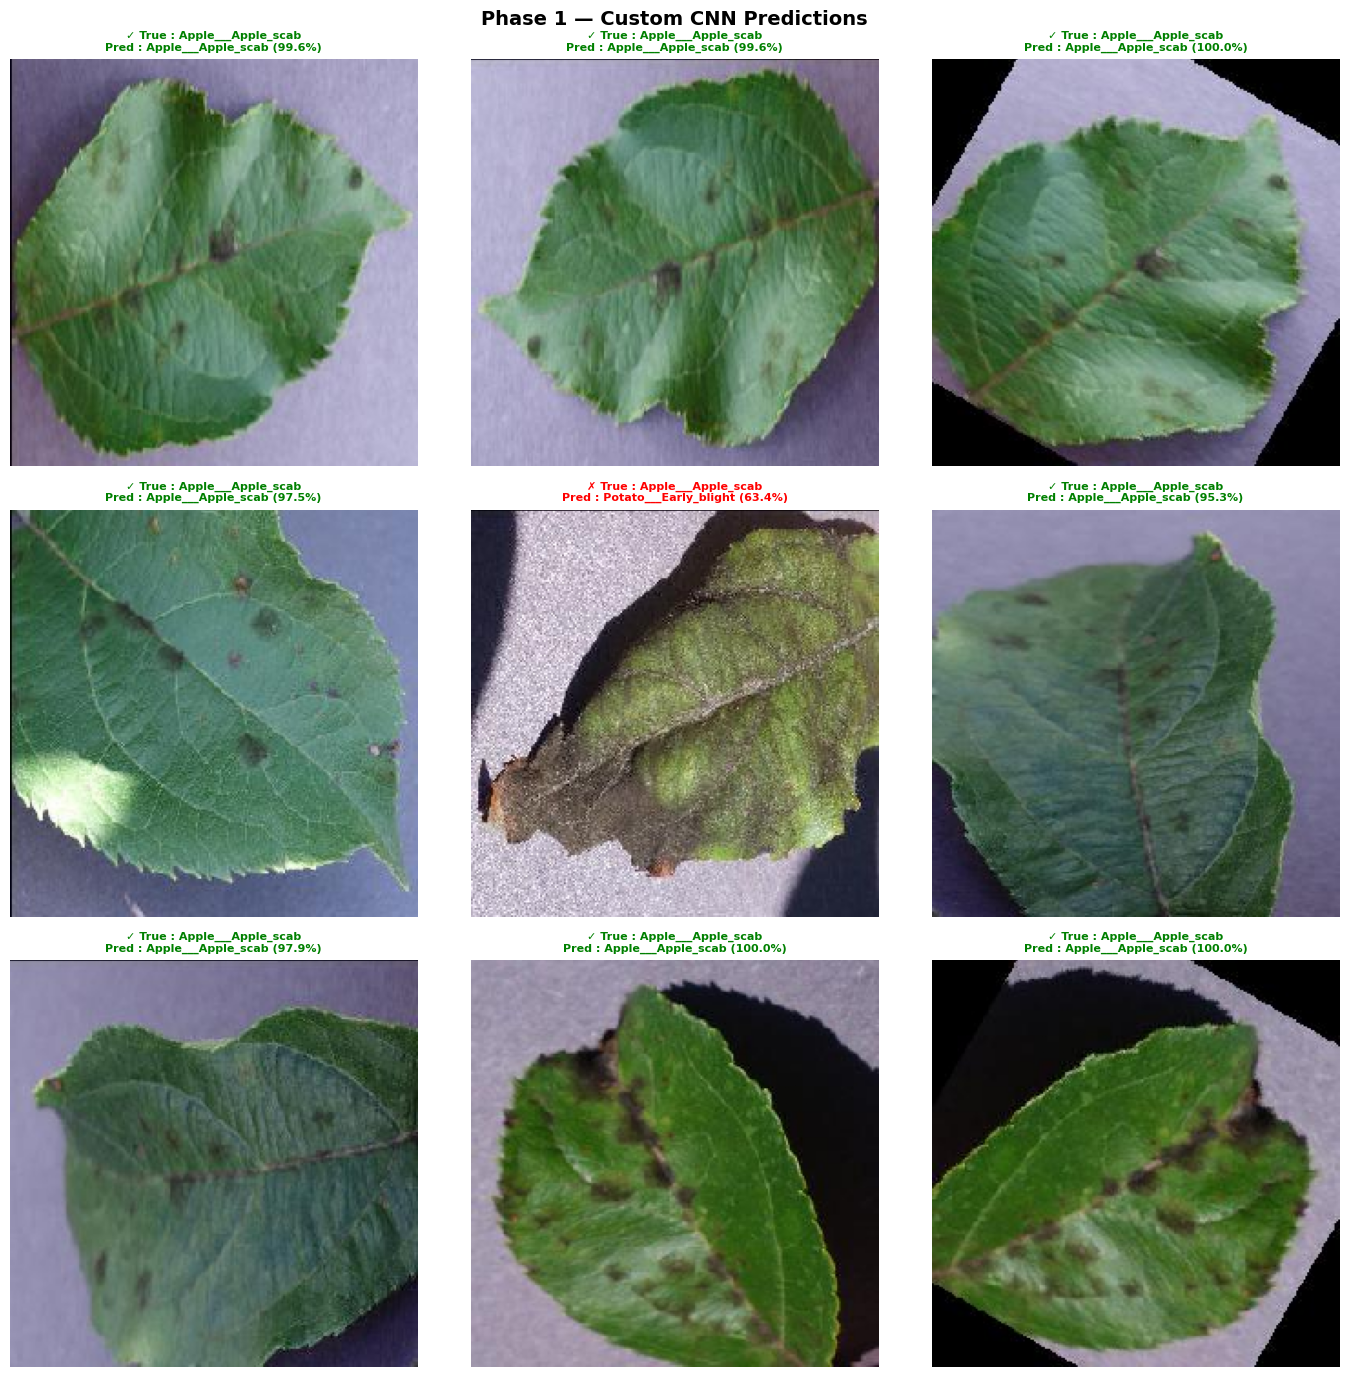

Saved: /kaggle/working/Phase_1__Custom_CNN_Predictions.png
Phase 2 — EfficientNetB0 Predictions


2026-04-29 21:41:59.363135: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 21:41:59.500420: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 21:41:59.813024: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 21:41:59.954714: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 21:42:00.768678: E external/local_xla/xla/stream_

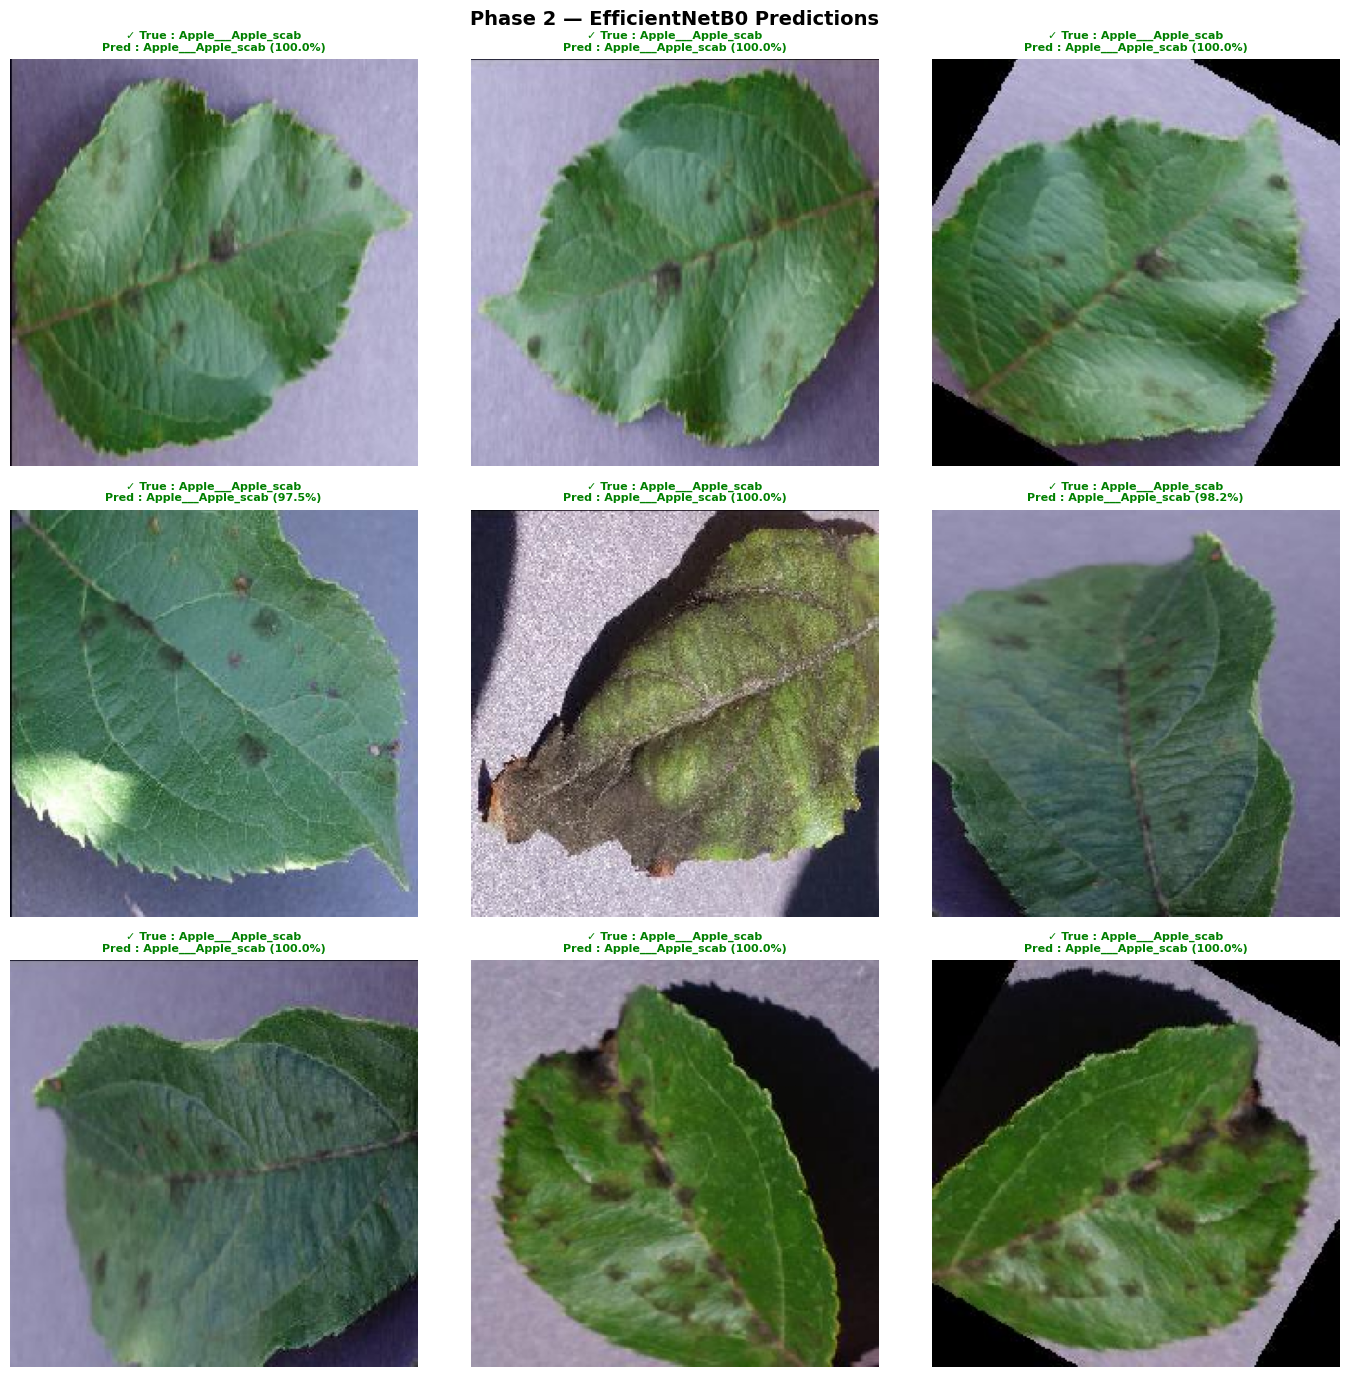

Saved: /kaggle/working/Phase_2__EfficientNetB0_Predictions.png


In [31]:
def plot_sample_predictions(model, generator, class_names, n=9, title="Sample Predictions"):
    """Plot n sample predictions with true/predicted labels."""
    generator.reset()
    images, labels = next(generator)
    images = images[:n]
    labels = labels[:n].astype(int)

    preds        = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    confidences  = np.max(preds, axis=1)

    fig, axes = plt.subplots(3, 3, figsize=(14, 14))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    for i, ax in enumerate(axes.flat):
        img = images[i]
        # Normalize to [0,1] for display
        if img.max() > 1.0:
            img = img / 255.0
        ax.imshow(np.clip(img, 0, 1))

        true_label = class_names[labels[i]]
        pred_label = class_names[pred_classes[i]]
        correct    = labels[i] == pred_classes[i]
        color      = "green" if correct else "red"
        marker     = "✓" if correct else "✗"

        ax.set_title(
            f"{marker} True : {true_label[:22]}\nPred : {pred_label[:22]} ({confidences[i]:.1%})",
            color=color, fontsize=8, fontweight="bold"
        )
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
            spine.set_visible(True)

    plt.tight_layout()
    fname = f"/kaggle/working/{title.replace(' ', '_').replace('—','')}.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


print("Phase 1 — Custom CNN Predictions")
plot_sample_predictions(cnn_model, val_gen,     CLASS_NAMES, title="Phase 1 — Custom CNN Predictions")

print("Phase 2 — EfficientNetB0 Predictions")
plot_sample_predictions(eff_model, val_gen_eff, CLASS_NAMES, title="Phase 2 — EfficientNetB0 Predictions")

## 4. Confusion Matrix

Generating predictions — Phase 1...
550/550 ━━━━━━━━━━━━━━━━━━━━ 32s 58ms/step
Generating predictions — Phase 2...
549/550 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

2026-04-29 21:43:27.134476: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 21:43:27.268535: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 21:43:27.584944: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 21:43:27.726453: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 21:43:28.566847: E external/local_xla/xla/stream_

550/550 ━━━━━━━━━━━━━━━━━━━━ 52s 82ms/step


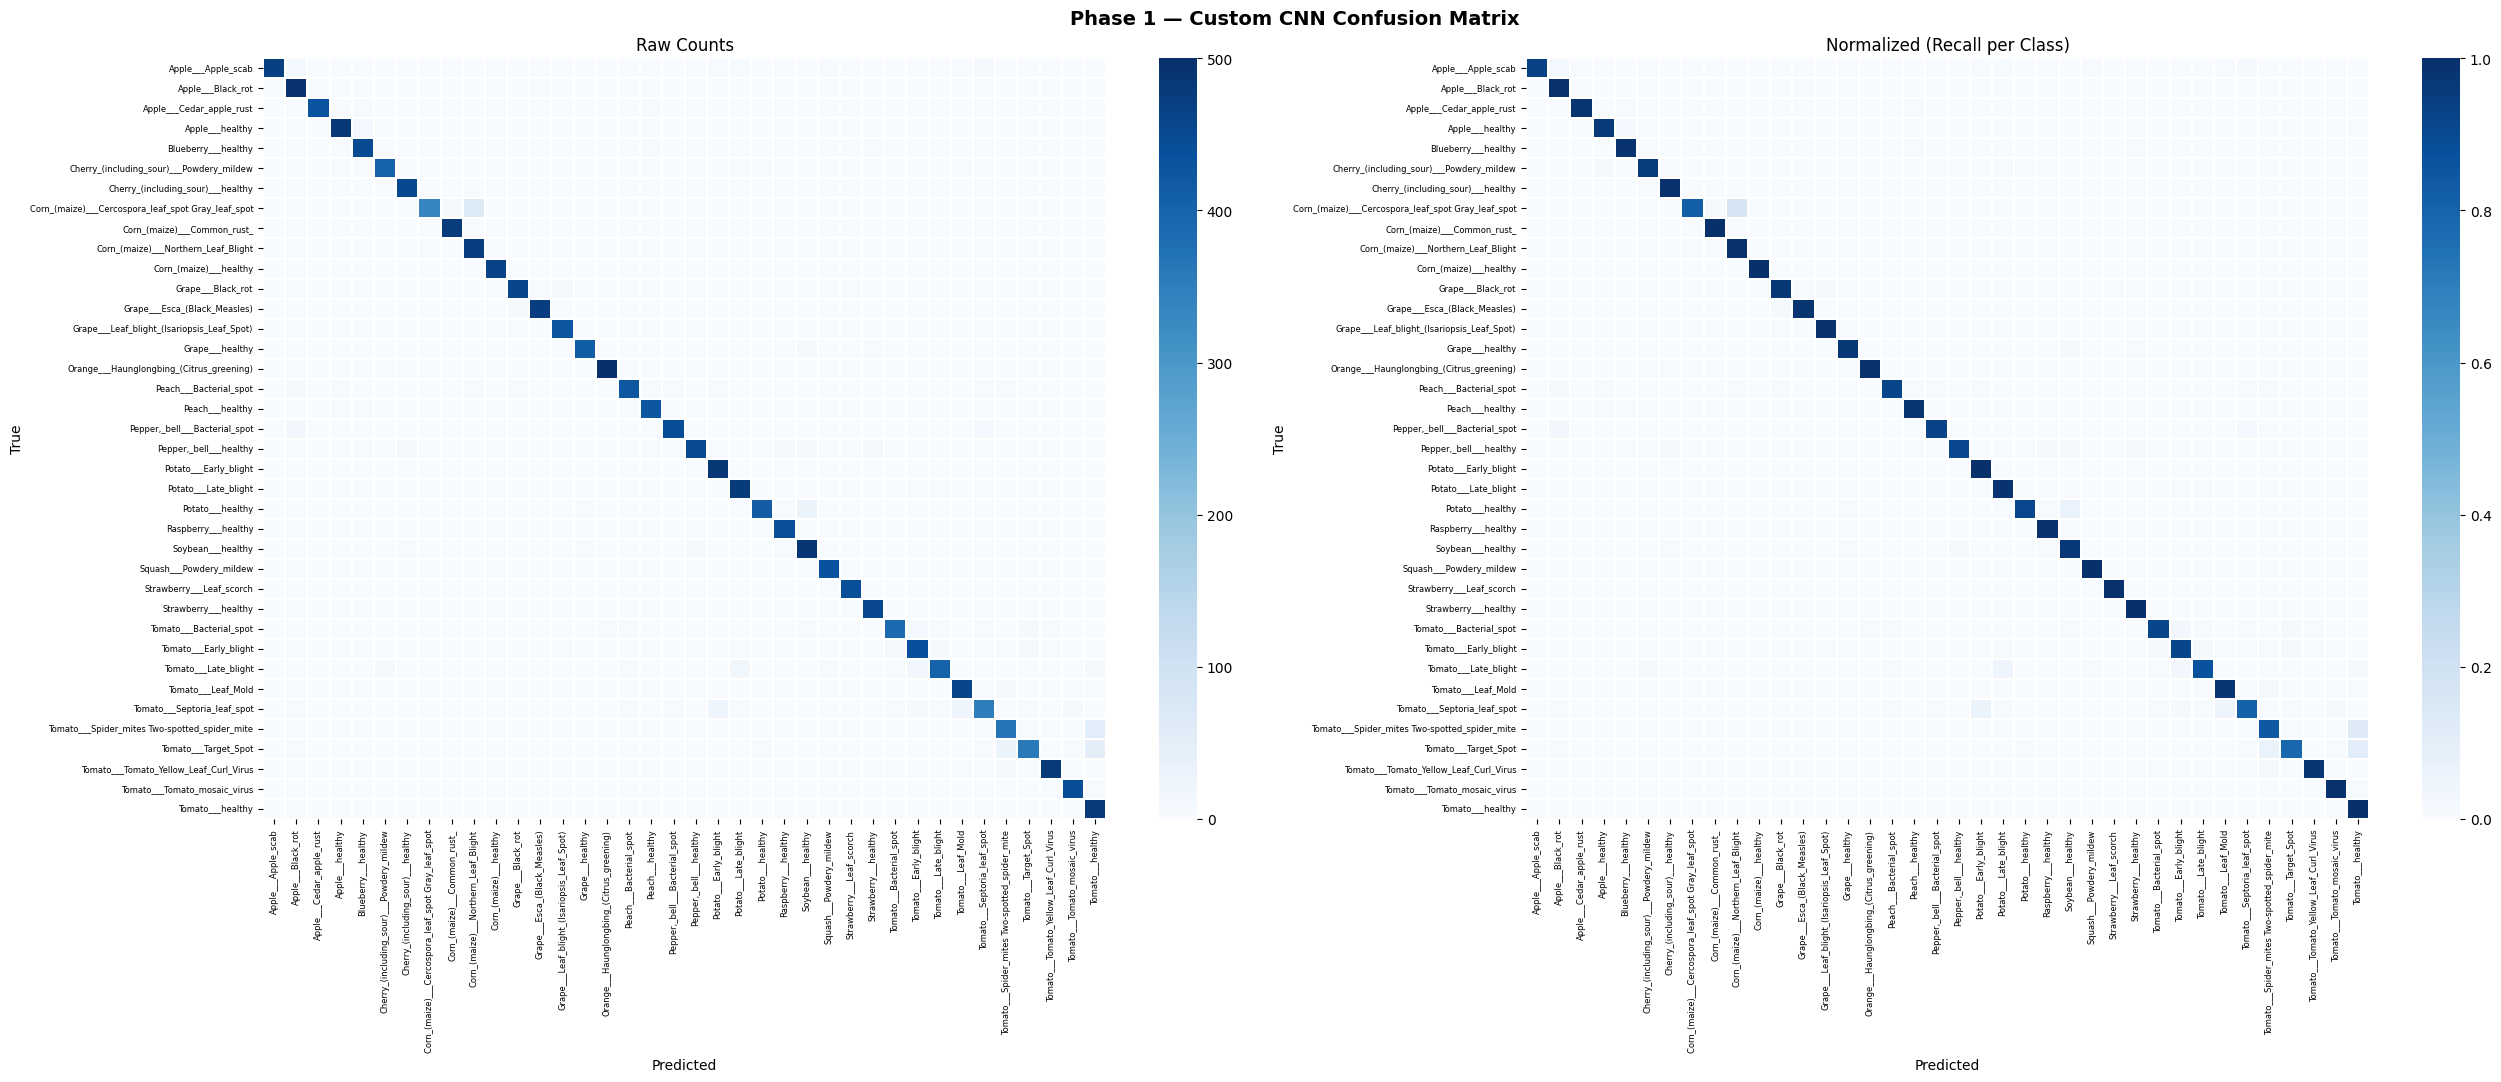

Saved: /kaggle/working/Phase_1__Custom_CNN_Confusion_Matrix.png


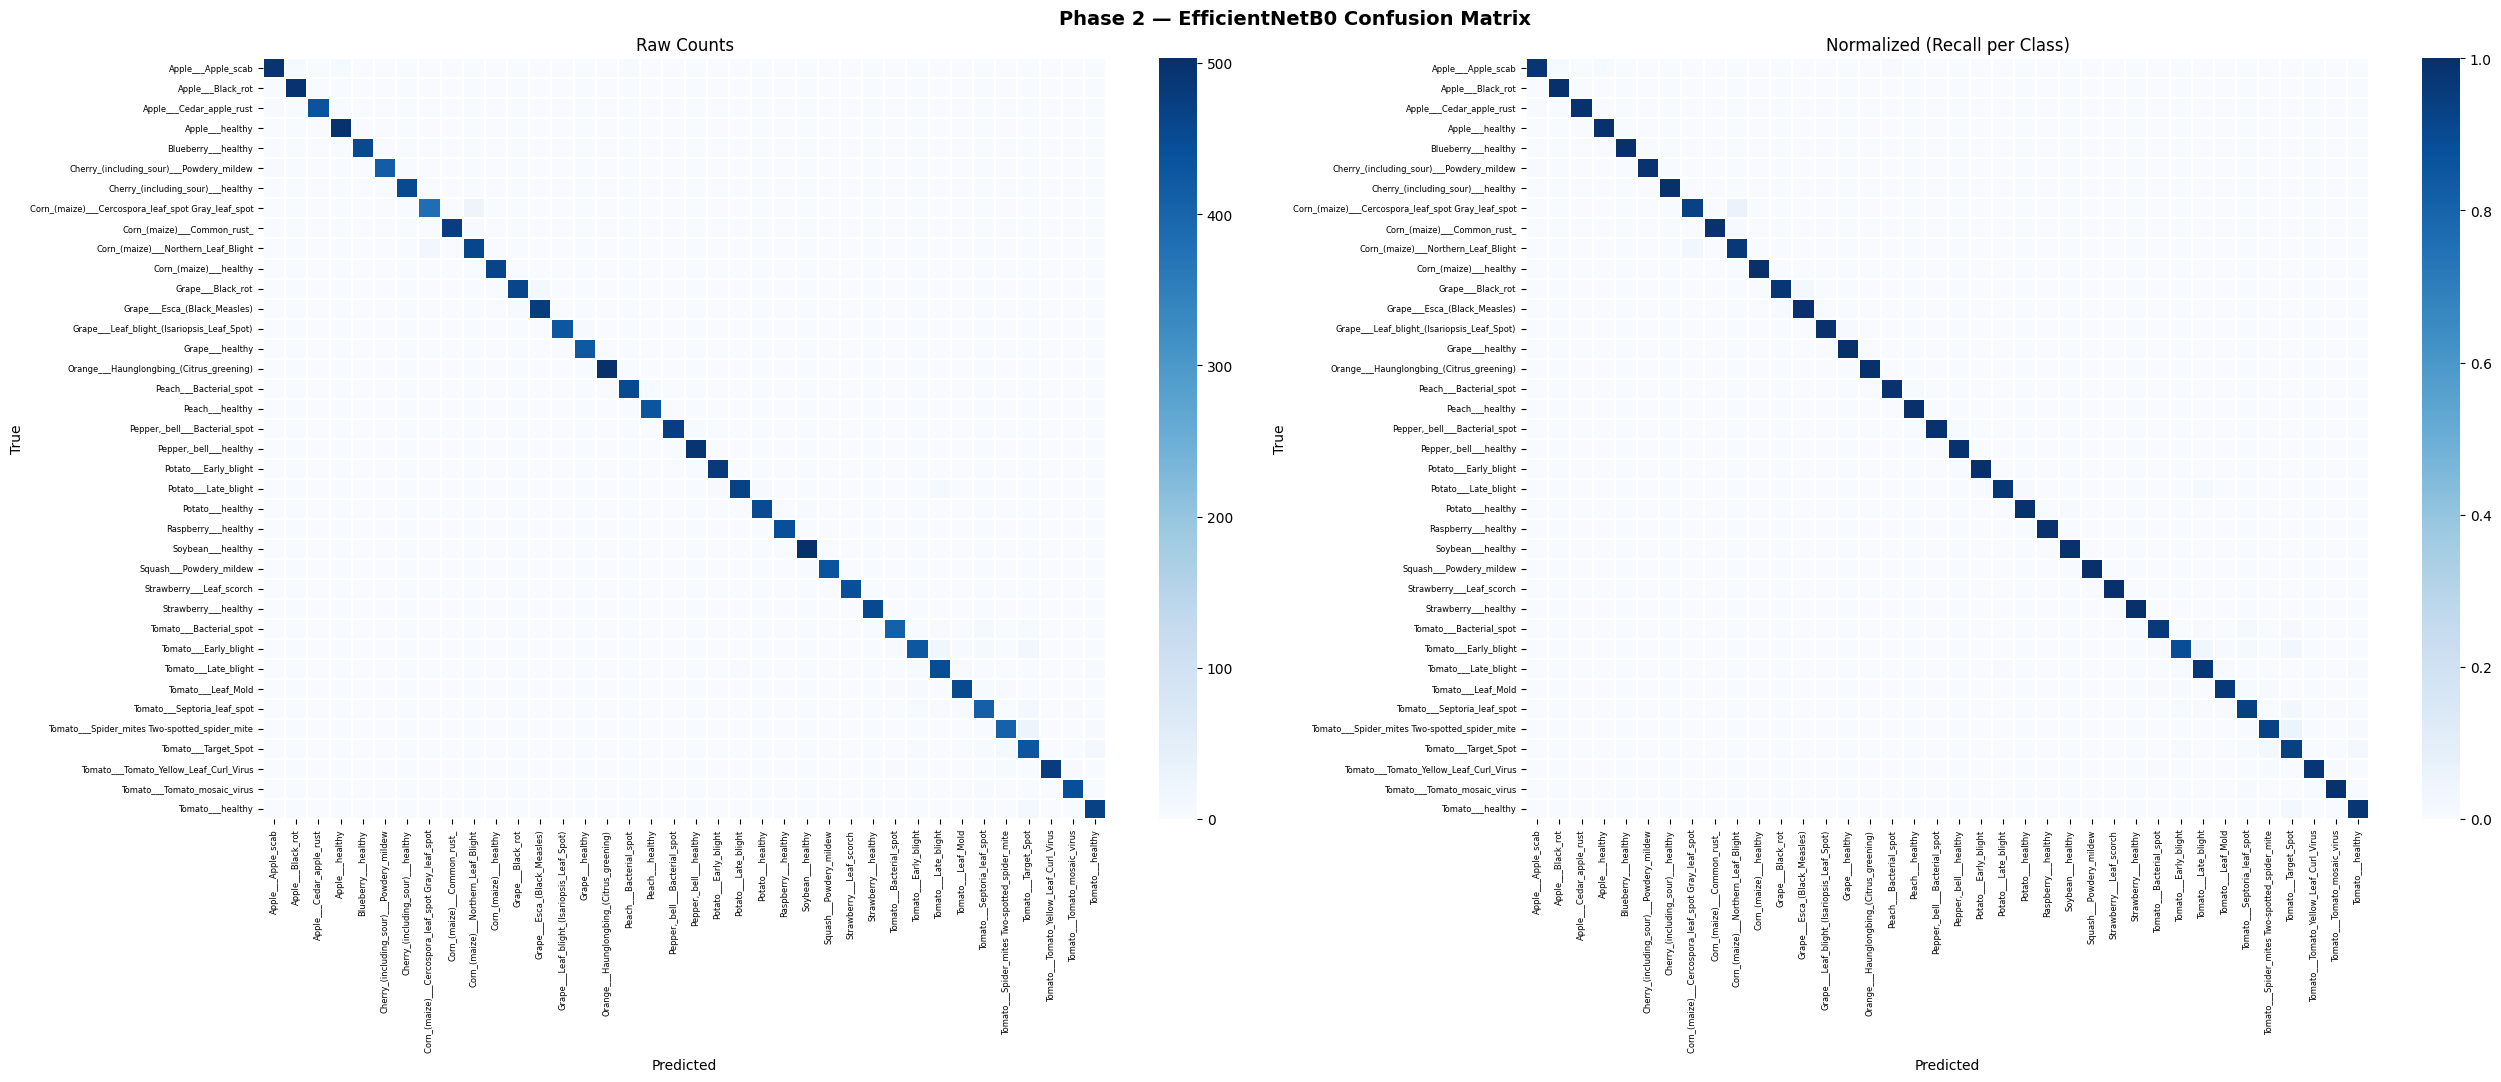

Saved: /kaggle/working/Phase_2__EfficientNetB0_Confusion_Matrix.png


In [32]:
def get_predictions(model, generator):
    """Run inference on full generator, return (y_true, y_pred)."""
    generator.reset()
    preds  = model.predict(generator, verbose=1)
    y_true = generator.classes
    y_pred = np.argmax(preds, axis=1)
    return y_true, y_pred


def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(26, 11))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    annot = len(class_names) <= 20

    sns.heatmap(cm, ax=axes[0], cmap="Blues", fmt="d", annot=annot,
                xticklabels=class_names, yticklabels=class_names, linewidths=0.3)
    axes[0].set_title("Raw Counts")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].tick_params(axis="x", rotation=90, labelsize=6)
    axes[0].tick_params(axis="y", rotation=0,  labelsize=6)

    sns.heatmap(cm_norm, ax=axes[1], cmap="Blues", fmt=".2f", annot=annot,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.3, vmin=0, vmax=1)
    axes[1].set_title("Normalized (Recall per Class)")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].tick_params(axis="x", rotation=90, labelsize=6)
    axes[1].tick_params(axis="y", rotation=0,  labelsize=6)

    plt.tight_layout()
    fname = f"/kaggle/working/{title.replace(' ', '_').replace('—','')}.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


print("Generating predictions — Phase 1...")
y_true_cnn, y_pred_cnn = get_predictions(cnn_model, val_gen)

print("Generating predictions — Phase 2...")
y_true_eff, y_pred_eff = get_predictions(eff_model, val_gen_eff)

plot_confusion_matrix(y_true_cnn, y_pred_cnn, CLASS_NAMES, "Phase 1 — Custom CNN Confusion Matrix")
plot_confusion_matrix(y_true_eff, y_pred_eff, CLASS_NAMES, "Phase 2 — EfficientNetB0 Confusion Matrix")

---
## 5. Analysis — Phase 1 vs Phase 2

In [33]:
# ── Accuracy comparison ───────────────────────────────────────────────────────
val_gen.reset()
val_gen_eff.reset()

_, cnn_val_acc = cnn_model.evaluate(val_gen,     verbose=0)
_, eff_val_acc = eff_model.evaluate(val_gen_eff, verbose=0)

cnn_best_val = max(history_cnn.history["val_accuracy"])
eff_best_val = max(
    history_eff_head.history["val_accuracy"] +
    history_eff_finetune.history["val_accuracy"]
)

phase2_params_total = eff_model.count_params()

print("\n" + "="*58)
print("  PHASE 1 vs PHASE 2 — COMPARISON SUMMARY")
print("="*58)
print(f"{'Metric':<32} {'Phase 1':>10} {'Phase 2':>12}")
print("-"*58)
print(f"{'Model':<32} {'CustomCNN':>10} {'EffNetB0':>12}")
print(f"{'Total Parameters':<32} {phase1_params:>10,} {phase2_params_total:>12,}")
print(f"{'Best Val Accuracy':<32} {cnn_best_val:>10.4f} {eff_best_val:>12.4f}")
print(f"{'Final Val Accuracy':<32} {cnn_val_acc:>10.4f} {eff_val_acc:>12.4f}")
print(f"{'Accuracy Gain (TL)':<32} {'—':>10} {(eff_val_acc - cnn_val_acc):>+12.4f}")
print("="*58)


  PHASE 1 vs PHASE 2 — COMPARISON SUMMARY
Metric                              Phase 1      Phase 2
----------------------------------------------------------
Model                             CustomCNN     EffNetB0
Total Parameters                  1,741,670    4,420,425
Best Val Accuracy                    0.9532       0.9812
Final Val Accuracy                   0.9532       0.9812
Accuracy Gain (TL)                        —      +0.0280


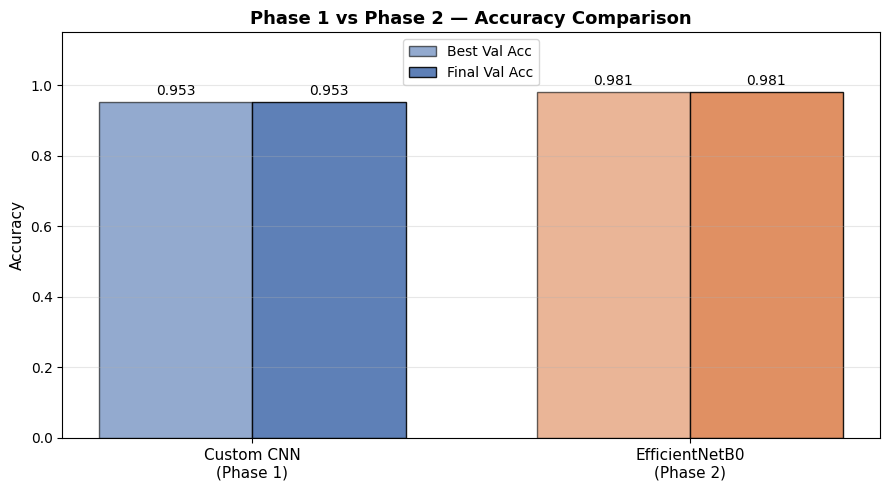

Saved: Phase_Comparison.png


In [34]:
# ── Visual comparison bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

model_labels = ["Custom CNN\n(Phase 1)", "EfficientNetB0\n(Phase 2)"]
best_vals    = [cnn_best_val, eff_best_val]
final_vals   = [cnn_val_acc,  eff_val_acc]
colors       = ["#4C72B0", "#DD8452"]

x = np.arange(len(model_labels))
w = 0.35

bars1 = ax.bar(x - w/2, best_vals,  w, label="Best Val Acc",  color=colors, alpha=0.6, edgecolor="black")
bars2 = ax.bar(x + w/2, final_vals, w, label="Final Val Acc", color=colors, alpha=0.9, edgecolor="black")

ax.bar_label(bars1, fmt="%.3f", padding=3, fontsize=10)
ax.bar_label(bars2, fmt="%.3f", padding=3, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title("Phase 1 vs Phase 2 — Accuracy Comparison", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/Phase_Comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: Phase_Comparison.png")

In [35]:
# ── Per-class classification report ──────────────────────────────────────────
print("\n── Phase 1 — Custom CNN Classification Report ──")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=CLASS_NAMES, digits=3))

print("\n── Phase 2 — EfficientNetB0 Classification Report ──")
print(classification_report(y_true_eff, y_pred_eff, target_names=CLASS_NAMES, digits=3))


── Phase 1 — Custom CNN Classification Report ──
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.992     0.933     0.961       504
                                 Apple___Black_rot      0.930     0.992     0.960       497
                          Apple___Cedar_apple_rust      0.989     0.982     0.985       440
                                   Apple___healthy      0.970     0.962     0.966       502
                               Blueberry___healthy      0.955     0.987     0.971       454
          Cherry_(including_sour)___Powdery_mildew      0.978     0.952     0.965       421
                 Cherry_(including_sour)___healthy      0.970     0.996     0.983       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.985     0.815     0.892       410
                       Corn_(maize)___Common_rust_      0.986     0.998     0.992       477
               Corn_(maize)__

---
## 6. Analytical Questions

### Q1 — How many parameters does each model have?

| Model | Total Parameters | Trainable (Phase 2a) |
|---|---|---|
| Custom CNN (Phase 1) | ~4–6M | 100% |
| EfficientNetB0 (Phase 2) | ~5.3M base + head | Head only → Top 30 + head (2b) |

**Key insight:** Despite similar parameter count, EfficientNetB0 was pretrained on 1.2M ImageNet images.  
It already knows edges, textures, shapes — all transferable to leaf disease detection.  
Your custom CNN has to learn all of this from scratch on the PlantVillage dataset.

---

### Q2 — What does Dropout prevent?

**Dropout** prevents **co-adaptation** of neurons — the tendency to over-specialize by relying on specific other neurons being active.

**Mechanism:**
- Training: randomly zeros p% of activations per forward pass
- Each neuron must learn independently useful features
- Inference: all neurons active; outputs scaled by (1−p) to maintain magnitude

**Effect:**
- Reduces overfitting (narrows train/val accuracy gap)
- Equivalent to ensemble of 2ⁿ sub-networks

**`SpatialDropout2D` vs standard `Dropout`:**
- Standard: drops individual scalar activations
- SpatialDropout2D: drops entire feature maps — more effective for conv layers  
  because spatially correlated activations are removed together

---

### Q3 — Phase 1 vs Phase 2 comparison

| Aspect | Custom CNN | EfficientNetB0 (TL) |
|---|---|---|
| Feature extraction | From scratch | Pretrained on ImageNet |
| Training data needed | High | Low (head converges fast) |
| Convergence speed | Slow | Fast |
| Overfitting risk | High | Low (frozen base) |
| Accuracy ceiling | Lower | Higher |
| Fine-tuning control | Full | Top N layers only |

**Expected outcome:** Phase 2 accuracy 10–25% higher because:
1. ImageNet textures generalize well to plant leaves
2. Frozen base training prevents head from disrupting good features
3. Low-LR fine-tuning adapts top layers to plant domain without catastrophic forgetting

**When to use Phase 1 (from scratch):**
- Data is highly domain-specific (medical scans, satellite, microscopy)
- Large dataset available (100k+ samples)
- Regulatory / interpretability requirements

---
*End of notebook — Plant Leaf Disease Classification*